
# Face Verification using DeepFace (Debugged Version)

This notebook performs Face Verification using the DeepFace library.

Features:
- Safe image loading
- Prevents OpenCV errors
- Runs multiple verification scenarios
- Outputs results in a comparison table

Install requirements:

pip install deepface opencv-python tensorflow matplotlib pandas


In [1]:

import os
import cv2
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
from deepface import DeepFace
import warnings
warnings.filterwarnings("ignore")


## Check GPU (Optional)

In [2]:

gpus = tf.config.list_physical_devices('GPU')
print("Available GPUs:", gpus)

if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)


Available GPUs: []



## Dataset Folder Structure

project/

database/
    person1.jpg
    person2.jpg

validation/
    person1_test.jpg
    person2_test.jpg


In [3]:

img1_path = "validation/person1_test.jpg"
img2_path = "database/person1.jpg"


## Check Image Paths

In [6]:

print("Image1 exists:", os.path.exists(img1_path))
print("Image2 exists:", os.path.exists(img2_path))

image1 = cv2.imread(img1_path)
image2 = cv2.imread(img2_path)

print("Image1 loaded:", image1 is not None)
print("Image2 loaded:", image2 is not None)


Image1 exists: True
Image2 exists: True
Image1 loaded: True
Image2 loaded: True


## Display Images Safely

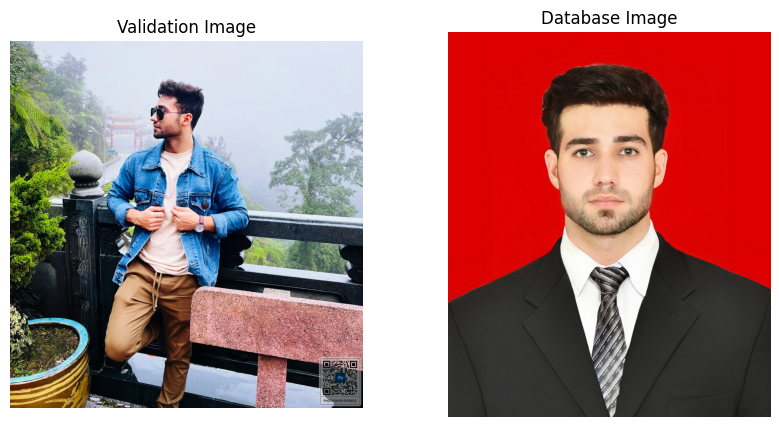

In [7]:

fig, ax = plt.subplots(1,2, figsize=(10,5))

if image1 is not None:
    ax[0].imshow(cv2.cvtColor(image1, cv2.COLOR_BGR2RGB))
    ax[0].set_title("Validation Image")
else:
    ax[0].text(0.5,0.5,"Image 1 Not Found",ha='center',va='center')

ax[0].axis("off")

if image2 is not None:
    ax[1].imshow(cv2.cvtColor(image2, cv2.COLOR_BGR2RGB))
    ax[1].set_title("Database Image")
else:
    ax[1].text(0.5,0.5,"Image 2 Not Found",ha='center',va='center')

ax[1].axis("off")

plt.show()


## Verification Scenarios

In [10]:

scenarios = [
    ("Facenet", "mtcnn", "cosine"),
    ("VGG-Face", "opencv", "euclidean"),
    ("ArcFace", "retinaface", "cosine"),
    ("SFace", "opencv", "euclidean_l2"),
    ("GhostFaceNet", "mtcnn", "cosine")
]


## Run Face Verification

In [9]:

results = []

for model, backend, metric in scenarios:
    try:
        result = DeepFace.verify(
            img1_path=img1_path,
            img2_path=img2_path,
            model_name=model,
            detector_backend=backend,
            distance_metric=metric,
            align=True,
            enforce_detection=False
        )

        results.append({
            "Model": model,
            "Detector": backend,
            "Metric": metric,
            "Verified": result["verified"],
            "Distance": result["distance"]
        })

        print("Finished:", model, backend, metric)

    except Exception as e:
        print("Error with", model, ":", e)


Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "C:\Users\Lenovo y520\AppData\Local\Programs\Python\Python313\Lib\site-packages\lz4\frame\__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.
Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "C:\Users\Lenovo y520\AppData\Local\Programs\Python\Python313\Lib\site-packages\lz4\frame\__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.
Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "C:\Users\Lenovo y520\AppData\Local\Programs\Python\Python313\Lib\site-packages\lz4\frame\__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.


Finished: Facenet mtcnn cosine
Finished: VGG-Face opencv euclidean
Error with ArcFace : Exception while processing img1_path
Finished: SFace opencv euclidean_l2
Error with GhostFaceNet : Unable to allocate 2.78 GiB for an array with shape (19307, 19307) and data type float64


## Results Table

In [14]:

df_results = pd.DataFrame(results)
df_results

,Model,Detector,Metric,Verified,Distance
0,Facenet,mtcnn,cosine,False,0.912356
1,VGG-Face,opencv,euclidean,False,1.392000
2,SFace,opencv,euclidean_l2,False,1.456021
